Customer Segmentation using K-Means Clustering and PCA

In [72]:
import pandas as pd

df = pd.read_csv('/content/q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


The dataset contains customer behavior features such as spending, visits, and purchase patterns. The goal is to segment customers into groups using K-Means clustering.

In [73]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


,0
age,0
annual_spend,0
visits_per_month,0
basket_size,0
days_since_last_visit,0
num_categories_purchased,0


The dataset structure and missing values were analyzed to ensure data quality before applying machine learning techniques.

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Feature scaling is essential before applying K-Means clustering because it is a distance-based algorithm. Scaling ensures all features contribute equally.

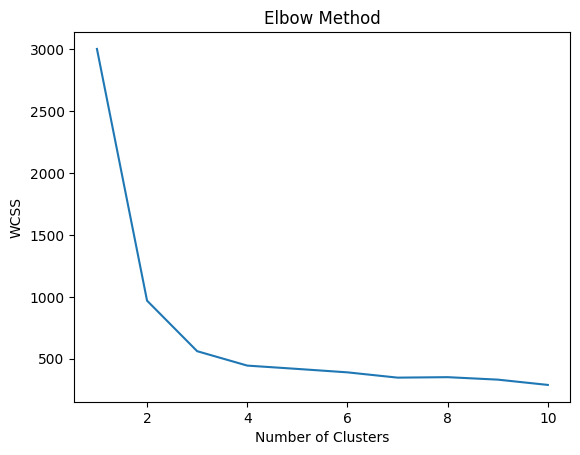

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

The elbow method helps determine the optimal number of clusters. The point where the curve bends indicates the best number of clusters, which is chosen as 3.

In [76]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [77]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


Cluster 0 represents customers with relatively lower spending and fewer visits.
Cluster 1 represents high-value customers who spend more and visit frequently.
Cluster 2 represents moderate customers with average spending and engagement levels.
These segments can help businesses target marketing strategies effectively.

In [78]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [79]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [80]:
loadings = pd.DataFrame(pca.components_, columns=df.columns[:-1])
loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
1,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


The PCA loadings indicate how each feature contributes to the principal components.
Features with higher absolute values have a stronger influence on PC1 and PC2.
This helps in understanding which customer attributes are most important in defining the clusters.

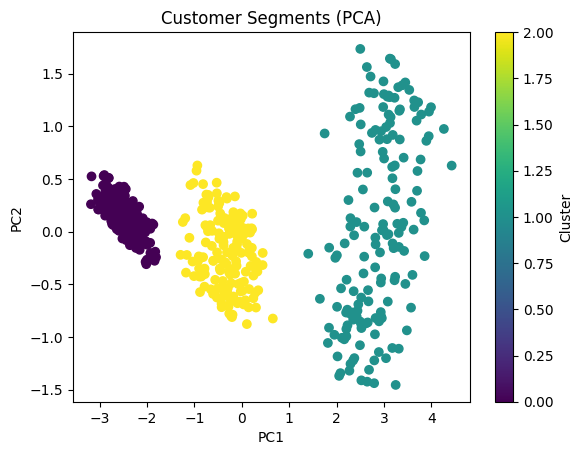

In [81]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.title("Customer Segments (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.show()

Customer segmentation was successfully performed using K-Means clustering. PCA helped visualize the clusters effectively. This analysis provides valuable insights into customer groups and can support better business decisions.